In [2]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()

X=df.drop(columns="class")
y=df["class"]

# label binaria, classificazione binaria

print(df.isna().mean() * 100) # nessun valore mancante da imputare




feature_0     0.0
feature_1     0.0
feature_2     0.0
feature_3     0.0
feature_4     0.0
feature_5     0.0
feature_6     0.0
feature_7     0.0
feature_8     0.0
feature_9     0.0
feature_10    0.0
feature_11    0.0
feature_12    0.0
feature_13    0.0
feature_14    0.0
class         0.0
dtype: float64


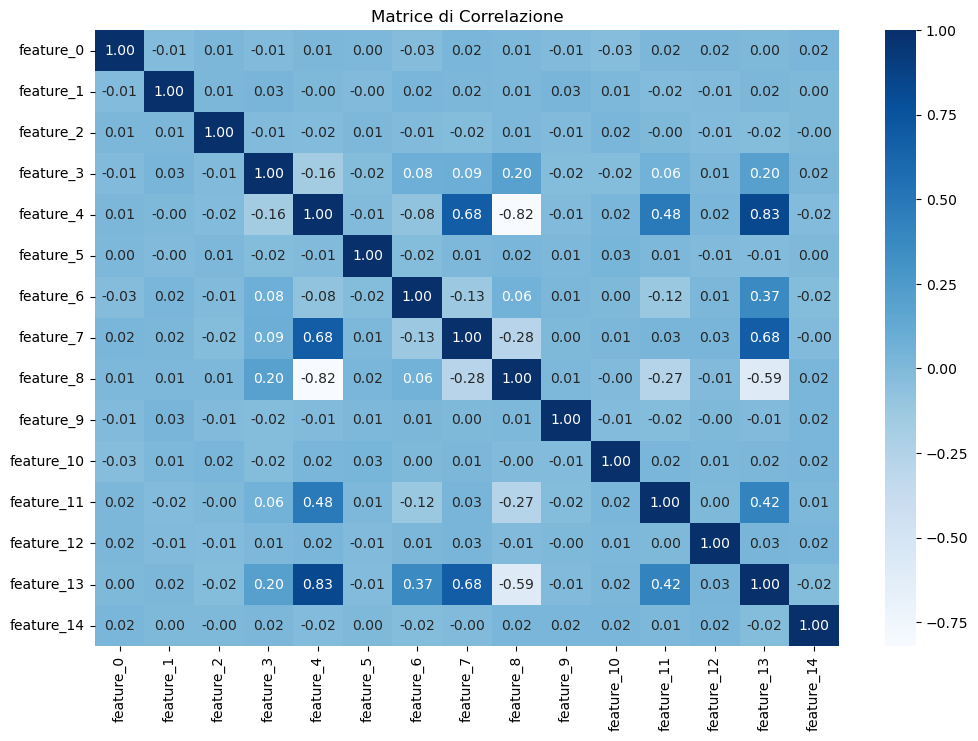

In [3]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, stratify=y, random_state=42, test_size=0.05)

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_train.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="Blues", annot=True, fmt=".2f")
plt.title("Matrice di Correlazione")
plt.show()

In [4]:
# Gestione dei dati multicollineari
features_multicollineari = []

threshold = 0.80

for i, col1 in enumerate(corr_matrix.columns):
    for col2 in (corr_matrix.columns[i+1:]):
        corr_val = corr_matrix.loc[col1,col2]
        if(abs(corr_val) > threshold):
            features_multicollineari.append([corr_val,col1,col2])
print(features_multicollineari)

# Eliminiamo 3 feature: 4,8,13 e sostituiamo creando una combinazione lineare di queste
# Lavoriamo pero' su dati scalati

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.set_output(transform="pandas")

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

corr_group = ['feature_4','feature_8','feature_13']
X_train_scaled['feat_combined'] = X_train_scaled[corr_group].mean(axis=1) 
X_train_scaled = X_train_scaled.drop(columns=corr_group)
X_test_scaled['feat_combined'] = X_test_scaled[corr_group].mean(axis=1)
X_test_scaled = X_test_scaled.drop(columns=corr_group)

print(X_train_scaled.shape)



[[np.float64(-0.8208962707252971), 'feature_4', 'feature_8'], [np.float64(0.8346958596073489), 'feature_4', 'feature_13']]
(2850, 13)


In [5]:
import numpy as np

# Rilevamento: solo triangolo superiore (niente diagonale, niente doppioni)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
pairs = upper.stack()
print(pairs[pairs.abs() > threshold])

# Una versione molto piu' corta e veloce per rilevare le feature multicollineari

feature_4  feature_8    -0.820896
           feature_13    0.834696
dtype: float64


In [6]:
# Feature selection tramite fisher score
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
selector.set_output(transform='pandas')
selector.fit(X_train_scaled, y_train)
print(selector.get_feature_names_out())
X_train_final = selector.transform(X_train_scaled)
X_test_final = selector.transform(X_test_scaled)

print(X_train_final.shape)
print(X_test_final.shape)

['feature_1' 'feature_2' 'feature_3' 'feature_5' 'feature_6' 'feature_9'
 'feature_10' 'feature_11' 'feature_14' 'feat_combined']
(2850, 10)
(150, 10)


In [7]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

n_samples = X_train_final.shape[0]

param_grid = {
    'C' : [1, 1/ np.sqrt(n_samples)],
    'kernel' : ['rbf', 'poly'],
    'degree' : [3,4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svc = SVC(random_state=42, probability=True)
grid = GridSearchCV(estimator=svc, param_grid=param_grid,cv=cv, scoring='accuracy')

grid.fit(X_train_final, y_train)
best_estimator = grid.best_estimator_
best_score = grid.best_score_
best_params = grid.best_params_

test_acc = best_estimator.score(X_test_final, y_test)
svc_prob = best_estimator.predict_proba(X_test_final)[:,1]

print(f"Miglior classificatore: {best_estimator}\nAccuracy media in CV: {best_score}\nMigliori iperparametri:{best_params}")
print(f"Test Accuracy: {test_acc}")

Miglior classificatore: SVC(C=1, probability=True, random_state=42)
Accuracy media in CV: 0.904561403508772
Migliori iperparametri:{'C': 1, 'degree': 3, 'kernel': 'rbf'}
Test Accuracy: 0.92


modello caricato


Epoch    1: 100%|██████████| 81/81 [00:00<00:00, 122.36it/s]


  >> checkpoint salvato: epoca 1, val acc 0.8982
Train loss: 0.4487
Validation loss: 0.3029
Test loss: 0.3328 Accuracy:   0.88
Metrics:
precision_score:   0.88  recall_score:   0.88  f1_score:   0.88  


Epoch    2: 100%|██████████| 81/81 [00:00<00:00, 325.30it/s]


  >> checkpoint salvato: epoca 2, val acc 0.9018
Train loss: 0.2861
Validation loss: 0.2400
Test loss: 0.3052 Accuracy:   0.90
Metrics:
precision_score:   0.91  recall_score:   0.90  f1_score:   0.90  


...

Train loss: 0.2219
Validation loss: 0.2182
Test loss: 0.2365 Accuracy:   0.89
Metrics:
precision_score:   0.90  recall_score:   0.89  f1_score:   0.89  


Epoch   13: 100%|██████████| 81/81 [00:00<00:00, 358.41it/s]


Train loss: 0.2266
Validation loss: 0.2215
Test loss: 0.2596 Accuracy:   0.91
Metrics:
precision_score:   0.91  recall_score:   0.91  f1_score:   0.91  


Epoch   14: 100%|██████████| 81/81 [00:00<00:00, 329.27it/s]


Train loss: 0.2153
Validation loss: 0.2381
Test loss: 0.2715 Accuracy:   0.93
Metrics:
precision_score:   0.93  recall_score:   0.93  f1_score:   0.93  


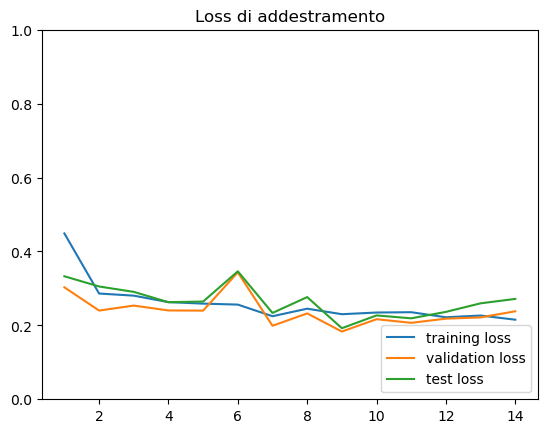

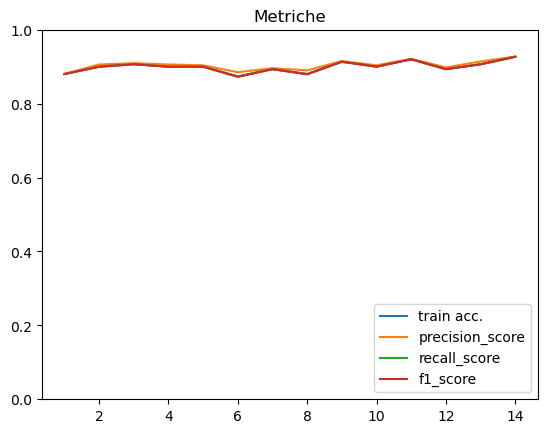

In [8]:
# Rete neurale
import torch 
import torchnn as tnn
from torch import nn
from torch.utils.data import Dataset, DataLoader

class Data(Dataset):

    def __init__(self, X,y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index], self.y[index]

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(X_train_final, y_train, stratify=y_train, test_size=0.10, random_state=42)

train_data = Data(X_train_nn,y_train_nn)
val_data = Data(X_val_nn,y_val_nn)
test_data = Data(X_test_final, y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

input_dim = X_train_nn.shape[1]

class DataNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32,16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16,2),  
        )

    def forward(self,x):
        return self.layers(x)

    print("modello caricato")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DataNet(input_dim=input_dim).to(device)

import torch.optim as optim

optimizer = optim.RMSprop(model.parameters(), centered=True, weight_decay=0.001, momentum=0.1)
early_stopping = tnn.EarlyStopping(patience=5, min_delta=0.01)
#scheduler = optim.lr_scheduler.LinearLR(optimizer=optimizer)
loss_fn=nn.CrossEntropyLoss()

train_loss, validation_loss, test_loss, accuracy, test_metrics = tnn.train_test(
    model=model,
    optimizer=optimizer,
    device=device,
    #scheduler=scheduler,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    epochs=50,
    train_loss_fn=loss_fn,
    test_loss_fn=loss_fn,
    early_stopping=early_stopping,
    val_dataloader=val_loader
)

tnn.save_model(
    net=model,
    optimizer=optimizer, 
    current_epoch=len(validation_loss), 
    train_loss=train_loss, 
    val_loss=validation_loss, 
    test_loss=test_loss,
    accuracy=accuracy,
    metrics=test_metrics,
    path="best_model.pt"
               )

tnn.displayLosses(train_loss, test_loss, validation_loss)
tnn.displayMetrics(accuracy, test_metrics)


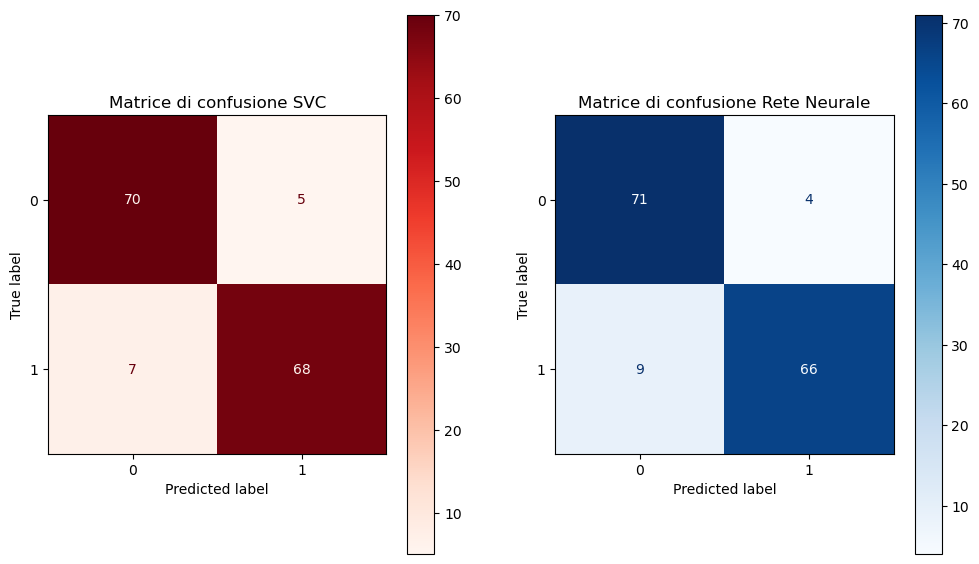

Accuracy in test di SVC: 0.92
Accuracy in test della rete neurale: 0.91
AUC SVC: 0.9595
AUC rete neurale: 0.9689


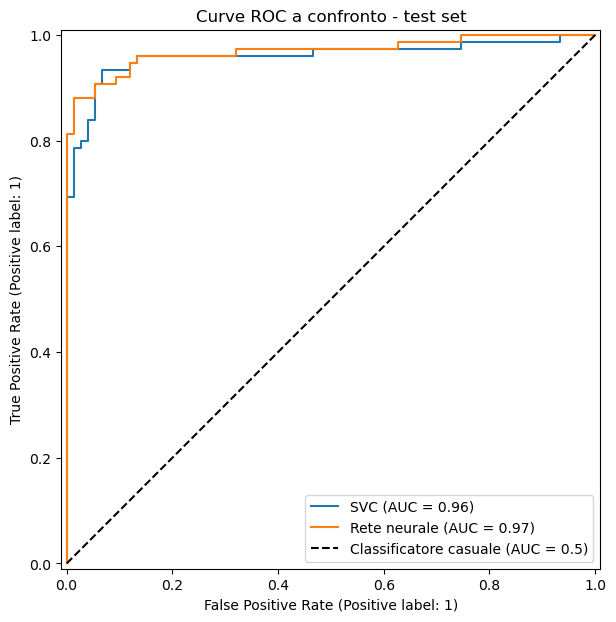

In [22]:
def evaluate(model, loss_fn, test_loader, device):

    model.eval()
    nn_true,nn_pred,nn_prob,losses = [],[],[],[]

    num_batches  = len(test_loader)

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            # Softmax prende il vettore di numeri reali e lo trasforma in una probabilita'
            prob = torch.softmax(logits, dim=1)
            # Argmax evaluates an array or function and returns the index position of the maximum value (the "winner").
            pred = torch.argmax(prob, dim=1)

            losses.append(loss_fn(logits, y_batch).item())
            nn_true.extend(y_batch.cpu().numpy())
            nn_pred.extend(pred.cpu().numpy())
            nn_prob.extend(prob.cpu().numpy())

    nn_test_loss = sum(losses) / num_batches

    nn_true=np.array(nn_true)
    nn_pred=np.array(nn_pred)
    nn_prob=np.array(nn_prob)

    return nn_true, nn_pred, nn_prob, nn_test_loss

best_model, best_optimizer, checkpoint  = tnn.load_model("best_model.pt", model=model, optimizer=optimizer, device=device)

nn_true, nn_pred, nn_prob, nn_test_loss = evaluate(best_model, loss_fn, test_loader, device)

# === Matrici di confusioni ===

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, accuracy_score

fig, (ax1,ax2) = plt.subplots(1,2, sharex=True, figsize=(12,7))

svc_pred = best_estimator.predict(X_test_final)
ConfusionMatrixDisplay.from_predictions(y_test, svc_pred, cmap="Reds", ax=ax1)
ax1.set_title("Matrice di confusione SVC")

ConfusionMatrixDisplay.from_predictions(nn_true, nn_pred, cmap="Blues", ax=ax2)
ax2.set_title("Matrice di confusione Rete Neurale")

plt.show()

# ===Accuracy ===

svc_acc = accuracy_score(y_test, svc_pred)
nn_acc = accuracy_score(nn_true, nn_pred)

print(f"Accuracy in test di SVC: {svc_acc}")
print(f"Accuracy in test della rete neurale: {nn_acc:.2f}")

# === Curva ROC e AUC ===
svc_auc = roc_auc_score(y_test, svc_prob)
nn_auc  = roc_auc_score(nn_true, nn_prob[:, 1])
print(f"AUC SVC: {svc_auc:.4f}")
print(f"AUC rete neurale: {nn_auc:.4f}")

fig, ax = plt.subplots(figsize=(7, 7))
RocCurveDisplay.from_predictions(y_test, svc_prob, name="SVC", ax=ax)
RocCurveDisplay.from_predictions(nn_true, nn_prob[:, 1], name="Rete neurale", ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Classificatore casuale (AUC = 0.5)")
ax.set_title("Curve ROC a confronto - test set")
ax.legend()
plt.show()
